In [ ]:
# Standard Library
import os, sys, json, math, time, csv, shutil, traceback
from pathlib import Path

# Third-Party
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import kagglehub
from scipy import stats as scipy_stats
from scipy.ndimage import gaussian_filter1d
from scipy.ndimage import label as nd_label
from ultralytics import YOLO

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F

# Sklearn
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, matthews_corrcoef,
    balanced_accuracy_score, cohen_kappa_score,
    average_precision_score, precision_recall_curve,
)
import seaborn as sns

print("\u2705 Imports complete.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Imports complete.


In [ ]:
path = kagglehub.dataset_download("shahliza27/ur-fall-detection-dataset")
print("Dataset path:", path)

Using Colab cache for faster access to the 'ur-fall-detection-dataset' dataset.
Dataset path: /kaggle/input/ur-fall-detection-dataset


In [ ]:
URFALL_SRC = "/kaggle/input/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb"
URFALL_DST = "/content/UR_FALL"

if os.path.exists(URFALL_DST):
    print(f"{URFALL_DST} already exists. Skipping.")
else:
    shutil.copytree(URFALL_SRC, URFALL_DST)
    print(f"Copied to {URFALL_DST}")

Copied to /content/UR_FALL


In [ ]:
SOURCE_ROOT = "/content/UR_FALL"
DEST_ROOT   = "/content/UR_FALL_32"
os.makedirs(DEST_ROOT, exist_ok=True)

skipped = []
for folder in sorted(os.listdir(SOURCE_ROOT)):
    src_folder = os.path.join(SOURCE_ROOT, folder)
    if not os.path.isdir(src_folder):
        continue
    dst_folder = os.path.join(DEST_ROOT, folder)
    os.makedirs(dst_folder, exist_ok=True)

    images = sorted([
        f for f in os.listdir(src_folder)
        if f.lower().endswith(".png") or f.lower().endswith(".jpg")
    ])
    N = len(images)
    if N < 32:
        skipped.append(f"{folder} ({N} frames)")
        continue

    for idx in np.linspace(0, N - 1, 32, dtype=int):
        shutil.copy(
            os.path.join(src_folder, images[idx]),
            os.path.join(dst_folder, images[idx])
        )

print(f"\u2705 Frame extraction complete. Skipped {len(skipped)}: {skipped}")

✅ Frame extraction complete. Skipped 0: []


In [ ]:
# ── Output paths ──────────────────────────────────────────────────────────
DATA_ROOT    = "/content/UR_FALL_32"
STAGE1_DIR   = "/content/stage1_output"
STAGE2_DIR   = "/content/stage2_output"
STAGE3_DIR   = "/content/stage3_output"   # cumulative JSON (s1+s2+s3 per video)
STAGE4_DIR   = "/content/stage4_output"   # stage3 JSON + stage4 block appended
SEQUENCE_CSV = "/content/sequence_features.csv"   # per-frame BiLSTM input
RESULTS_CSV  = "/content/results.csv"             # one row per video, all scores

VIS_ROOT = "/content/visualisation"
VIS_S1   = os.path.join(VIS_ROOT, "stage1")
VIS_S2   = os.path.join(VIS_ROOT, "stage2")
VIS_S3   = os.path.join(VIS_ROOT, "stage3")

for d in [STAGE1_DIR, STAGE2_DIR, STAGE3_DIR, STAGE4_DIR, VIS_S1, VIS_S2, VIS_S3]:
    os.makedirs(d, exist_ok=True)

print("\u2705 Directories ready.")

✅ Directories ready.


In [ ]:
# ── Constants ─────────────────────────────────────────────────────────────
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLIP_LEN   = 32
FRAME_SIZE = 224
NUM_KP     = 17
YOLO_IMGSZ = 640
YOLO_CONF  = 0.1
YOLO_IOU   = 0.5

FEATURE_COLUMNS = [
    "max_depth_drop_ratio",
    "height_drop_ratio",
    "peak_time_ratio",
    "ground_proximity",
    "peak_motion",
    "tilt_angle",
    "post_impact_stillness",
    "depth_peak_time_ratio",
    "tilt_relative_change",
    "motion_energy",
    "acceleration_energy",
    "duration_high_motion",
]

INPUT_DIM  = 12    # len(FEATURE_COLUMNS)
HIDDEN_DIM = 64

SKELETON_LINES = [
    (5,6),(5,11),(6,12),(11,12),
    (5,7),(7,9),(6,8),(8,10),
    (11,13),(13,15),(12,14),(14,16),
    (0,1),(0,2),(1,3),(2,4),
]


# ── Stage-1  3D-CNN ────────────────────────────────────────────────────────
class Stage1_3DCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv3d(3, 64, (3,7,7), (1,2,2), (1,3,3), padding_mode="replicate")
        self.bn1   = nn.BatchNorm3d(64)
        self.pool1 = nn.MaxPool3d((1,3,3), (1,2,2), (0,1,1))
        self.conv2 = nn.Conv3d(64, 128, 3, padding=1, padding_mode="replicate")
        self.bn2   = nn.BatchNorm3d(128)
        self.pool2 = nn.MaxPool3d(2, 2)
        self.conv3 = nn.Conv3d(128, 256, 3, padding=1, padding_mode="replicate")
        self.bn3   = nn.BatchNorm3d(256)
        self.conv4 = nn.Conv3d(256, 256, 3, padding=1, padding_mode="replicate")
        self.bn4   = nn.BatchNorm3d(256)
        self.global_pool = nn.AdaptiveAvgPool3d((1,1,1))
        self.dropout     = nn.Dropout(0.5)
        self.fc          = nn.Linear(256, 2)

    def forward(self, x, return_saliency=False):
        x   = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x   = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x   = F.relu(self.bn3(self.conv3(x)))
        sal = x.detach().pow(2).mean(dim=(1, 3, 4))
        T_p = sal.shape[1]
        em  = torch.ones(T_p, device=sal.device)
        em[0] = 0.05;  em[-1] = 0.5
        sal = sal * em
        sal = (sal - sal.min(1,keepdim=True)[0]) / (
              sal.max(1,keepdim=True)[0] - sal.min(1,keepdim=True)[0] + 1e-6)
        sal = F.softmax(sal * 5.0, dim=1)
        x   = F.relu(self.bn4(self.conv4(x)))
        x   = self.global_pool(x).flatten(1)
        x   = self.dropout(x)
        logits = self.fc(x)
        if return_saliency:
            return logits, sal
        return logits


# ── Stage-4  BiLSTM + SE Attention ────────────────────────────────────────
class SEBlock(nn.Module):
    def __init__(self, channel_dim, reduction=8):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channel_dim, channel_dim // reduction), nn.ReLU(),
            nn.Linear(channel_dim // reduction, channel_dim), nn.Sigmoid(),
        )
    def forward(self, x):
        return x * self.fc(x.mean(dim=1)).unsqueeze(1)


class BiLSTMAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(INPUT_DIM, HIDDEN_DIM,
                            batch_first=True,
                            bidirectional=True)

        self.norm = nn.LayerNorm(HIDDEN_DIM * 2)
        self.se   = SEBlock(HIDDEN_DIM * 2)
        self.attn = nn.Linear(HIDDEN_DIM * 2, 1)

        # MUST MATCH TRAINING
        self.fc = nn.Sequential(
            nn.Linear(HIDDEN_DIM * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x, mask):
        out, _ = self.lstm(x)
        out = self.norm(out)
        out = self.se(out)

        scores = self.attn(out).squeeze(-1)
        scores = scores.masked_fill(~mask, -1e9)

        weights = F.softmax(scores, dim=1)
        ctx = (out * weights.unsqueeze(-1)).sum(dim=1)

        return self.fc(ctx).squeeze()

print(f"\u2705 Model classes defined.  Device: {DEVICE}")

✅ Model classes defined.  Device: cuda


In [ ]:
# ── Checkpoint paths — UPDATE THESE BEFORE RUNNING ──────────────────────
STAGE1_CKPT = "/content/stage1.pth"

# Folder containing:
#   model_bed.pth  model_chair.pth  model_stand.pth
#   scaler_bed.pkl scaler_chair.pkl scaler_stand.pkl
#   config_bed.json config_chair.json config_stand.json
BILSTM_MODEL_DIR = "/content/bilstm_models"

STAGE5_PERCENTILE_FILE = "/content/stage5_percentiles.json"

# ── Stage-1 ───────────────────────────────────────────────────────────────
stage1_model = Stage1_3DCNN().to(DEVICE)
stage1_model.load_state_dict(torch.load(STAGE1_CKPT, map_location=DEVICE))
stage1_model.eval()
print("\u2705 Stage-1 3D-CNN loaded")

# ── MiDaS (Stage-3) ────────────────────────────────────────────────────────
print("Loading MiDaS...")
midas           = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
midas_transform = torch.hub.load("intel-isl/MiDaS", "transforms").small_transform
midas.to(DEVICE).eval()
print("\u2705 MiDaS loaded")

# ── YOLO pose (Stage-2) ────────────────────────────────────────────────────
yolo_model = YOLO("yolov8m-pose.pt")
print("\u2705 YOLOv8 pose loaded")

# ── BiLSTM models + scalers + temperatures (Stage-4) ─────────────────────
bilstm_models        = {}
bilstm_scalers       = {}
bilstm_temperatures  = {}
bilstm_logit_means   = {}
bilstm_logit_stds    = {}
bilstm_thresholds    = {}

stage4_model = BiLSTMAttention().to(DEVICE)
stage4_model.load_state_dict(
    torch.load(os.path.join(BILSTM_MODEL_DIR, "model.pth"),
               map_location=DEVICE)
)
stage4_model.eval()

stage4_scaler = joblib.load(
    os.path.join(BILSTM_MODEL_DIR, "scaler.pkl")
)

with open(os.path.join(BILSTM_MODEL_DIR, "config.json"), "r") as f:
    stage4_config = json.load(f)

STAGE4_THRESHOLD   = stage4_config["threshold"]
STAGE4_TEMPERATURE = stage4_config.get("temperature", 1.0)

print("✅ Stage-4 models + calibration loaded.")

# ── Stage-5 percentiles ────────────────────────────────────────────────────
with open(STAGE5_PERCENTILE_FILE) as f:
    stage5_percentiles = json.load(f)

print("✅ Stage-5 percentiles loaded")


# ── Stage-4 config (Unified Model) ─────────────────────────────────────────
with open(os.path.join(BILSTM_MODEL_DIR, "config.json")) as f:
    stage4_config = json.load(f)

STAGE4_THRESHOLD   = stage4_config["threshold"]
STAGE4_TEMPERATURE = stage4_config.get("temperature", 1.0)

print("✅ Stage-4 unified threshold + calibration loaded.")

✅ Stage-1 3D-CNN loaded
Loading MiDaS...


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Loading weights:  None


Using cache found in /root/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master


✅ MiDaS loaded
✅ YOLOv8 pose loaded
✅ Stage-4 models + calibration loaded.
✅ Stage-5 percentiles loaded
✅ Stage-4 unified threshold + calibration loaded.


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# HELPER — exhaustive temporal feature extractor
# Used by Stage-2 (pose signals) and Stage-3 (depth signal)
# ═══════════════════════════════════════════════════════════════════════════
def all_temporal_features(values, prefix, saliency_weights=None):
    arr = np.array(values, dtype=np.float64)
    n   = len(arr)

    def r(v):
        v = float(v)
        return 0.0 if (math.isnan(v) or math.isinf(v)) else round(v, 6)

    ZERO_KEYS = [
        "max","min","mean","std","median","range","sum",
        "delta","abs_delta","norm_delta","linear_slope",
        "peak_pos","trough_pos","time_to_peak","peak_trough_gap",
        "pre_peak_slope","post_peak_slope","slope_ratio","curvature",
        "first_half_mean","second_half_mean","first_half_std","second_half_std",
        "half_mean_diff","half_mean_ratio",
        "first_third_mean","mid_third_mean","last_third_mean",
        "energy","skewness","kurtosis","iqr",
        "mean_crossings","zero_crossings","above_mean_ratio",
        "mean_abs_diff","max_diff","total_variation","rms_diff",
    ]
    if n == 0:
        out = {f"{prefix}_{k}": 0.0 for k in ZERO_KEYS}
        if saliency_weights is not None:
            for k in ["weighted_mean","weighted_std","weighted_peak_val","weighted_sum"]:
                out[f"{prefix}_{k}"] = 0.0
        return out

    sig_range  = float(np.max(arr) - np.min(arr))
    delta      = float(arr[-1] - arr[0])
    norm_delta = delta / sig_range if sig_range > 1e-9 else 0.0
    lin_coeff  = np.polyfit(np.arange(n), arr, 1)[0] if n > 1 else 0.0
    peak_idx   = int(np.argmax(arr))
    trough_idx = int(np.argmin(arr))
    peak_pos   = peak_idx   / max(n - 1, 1)
    trough_pos = trough_idx / max(n - 1, 1)
    pre_sl  = float(np.mean(np.diff(arr[:peak_idx+1]))) if peak_idx > 0     else 0.0
    post_sl = float(np.mean(np.diff(arr[peak_idx:])))   if peak_idx < n - 1 else 0.0
    curvature = np.polyfit(np.arange(n), arr, 2)[0] if n >= 3 else 0.0
    mid  = max(n // 2, 1)
    fh   = arr[:mid]
    sh   = arr[mid:] if mid < n else arr[-1:]
    t1   = max(n // 3, 1)
    t2   = max(2 * n // 3, t1 + 1)
    mean_v   = float(np.mean(arr))
    centered = arr - mean_v
    if n > 1:
        diffs = np.abs(np.diff(arr))
        mean_ad = float(np.mean(diffs));  max_d   = float(np.max(diffs))
        tot_var = float(np.sum(diffs));   rms_d   = float(np.sqrt(np.mean(diffs**2)))
    else:
        mean_ad = max_d = tot_var = rms_d = 0.0

    out = {
        f"{prefix}_max":              r(np.max(arr)),
        f"{prefix}_min":              r(np.min(arr)),
        f"{prefix}_mean":             r(np.mean(arr)),
        f"{prefix}_std":              r(np.std(arr)),
        f"{prefix}_median":           r(np.median(arr)),
        f"{prefix}_range":            r(sig_range),
        f"{prefix}_sum":              r(np.sum(arr)),
        f"{prefix}_delta":            r(delta),
        f"{prefix}_abs_delta":        r(abs(delta)),
        f"{prefix}_norm_delta":       r(norm_delta),
        f"{prefix}_linear_slope":     r(lin_coeff),
        f"{prefix}_peak_pos":         r(peak_pos),
        f"{prefix}_trough_pos":       r(trough_pos),
        f"{prefix}_time_to_peak":     r(peak_pos),
        f"{prefix}_peak_trough_gap":  r(abs(peak_pos - trough_pos)),
        f"{prefix}_pre_peak_slope":   r(pre_sl),
        f"{prefix}_post_peak_slope":  r(post_sl),
        f"{prefix}_slope_ratio":      r(pre_sl / (post_sl + 1e-9)),
        f"{prefix}_curvature":        r(curvature),
        f"{prefix}_first_half_mean":  r(float(np.mean(fh))),
        f"{prefix}_second_half_mean": r(float(np.mean(sh))),
        f"{prefix}_first_half_std":   r(float(np.std(fh))),
        f"{prefix}_second_half_std":  r(float(np.std(sh))),
        f"{prefix}_half_mean_diff":   r(float(np.mean(sh)) - float(np.mean(fh))),
        f"{prefix}_half_mean_ratio":  r(float(np.mean(sh)) / (float(np.mean(fh)) + 1e-9)),
        f"{prefix}_first_third_mean": r(float(np.mean(arr[:t1]))),
        f"{prefix}_mid_third_mean":   r(float(np.mean(arr[t1:t2]))),
        f"{prefix}_last_third_mean":  r(float(np.mean(arr[t2:])) if t2 < n else float(arr[-1])),
        f"{prefix}_energy":           r(float(np.sum(arr**2))),
        f"{prefix}_skewness":         r(float(scipy_stats.skew(arr))     if n >= 3 else 0.0),
        f"{prefix}_kurtosis":         r(float(scipy_stats.kurtosis(arr)) if n >= 4 else 0.0),
        f"{prefix}_iqr":              r(float(np.percentile(arr,75) - np.percentile(arr,25))),
        f"{prefix}_mean_crossings":   r(int(np.sum(np.diff(np.sign(centered)) != 0))),
        f"{prefix}_zero_crossings":   r(int(np.sum(np.diff(np.sign(arr)) != 0))),
        f"{prefix}_above_mean_ratio": r(float(np.sum(arr > mean_v) / n)),
        f"{prefix}_mean_abs_diff":    r(mean_ad),
        f"{prefix}_max_diff":         r(max_d),
        f"{prefix}_total_variation":  r(tot_var),
        f"{prefix}_rms_diff":         r(rms_d),
    }

    if saliency_weights is not None:
        w      = np.array(saliency_weights, dtype=np.float64)[:n]
        w      = w / (w.sum() + 1e-9)
        w_mean = float(np.sum(arr * w))
        com    = max(0, min(int(np.round(np.sum(np.arange(n) * w))), n - 1))
        out.update({
            f"{prefix}_weighted_mean":     r(w_mean),
            f"{prefix}_weighted_std":      r(float(np.sqrt(np.sum(w * (arr - w_mean)**2)))),
            f"{prefix}_weighted_peak_val": r(float(arr[com])),
            f"{prefix}_weighted_sum":      r(float(np.sum(arr * w))),
        })

    return out


print("\u2705 Temporal feature extractor defined.")

✅ Temporal feature extractor defined.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# STAGE 1 — 3D-CNN Saliency
# ═══════════════════════════════════════════════════════════════════════════
def _get_active_window(saliency, energy_threshold=0.15):
    thresh    = np.mean(saliency) + 0.5 * np.std(saliency)
    is_active = saliency > thresh
    labs, nf  = nd_label(is_active)
    if nf == 0:
        return 0, len(saliency) - 1, "Static/Uniform"
    total_e = np.sum(saliency)
    sig_idx = []
    for i in range(1, nf + 1):
        m = labs == i
        if np.sum(saliency[m]) / total_e > energy_threshold:
            sig_idx.extend(np.where(m)[0].tolist())
    if not sig_idx:
        pk = int(np.argmax(saliency))
        return max(0, pk - 2), min(len(saliency) - 1, pk + 2), "Peak Only"
    return int(min(sig_idx)), int(max(sig_idx)), "Global Event Zone"


def run_stage1(folder_name, image_paths):
    # image_paths: sorted list of exactly 32 uniformly-sampled images.
    # clip_indices[i] = i  (position i == image_paths index i)
    frames = []
    for p in image_paths:
        img = cv2.imread(p)
        img = cv2.resize(img, (FRAME_SIZE, FRAME_SIZE))
        frames.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    frames_np = np.array(frames, dtype=np.float32) / 255.0
    clip = torch.from_numpy(frames_np).permute(3,0,1,2).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        _, saliency = stage1_model(clip, return_saliency=True)

    sal_raw    = saliency.squeeze(0).cpu().numpy()
    sal_interp = np.interp(
        np.linspace(0, len(sal_raw)-1, CLIP_LEN),
        np.arange(len(sal_raw)), sal_raw
    )
    sal_smooth = gaussian_filter1d(sal_interp, sigma=1.2)
    start, end, status = _get_active_window(sal_smooth)

    meta = {
        "active_window":    [int(start), int(end)],
        "varying_k":        int(end - start + 1),
        "detection_status": status,
        "saliency_weights": sal_smooth.tolist(),
        "clip_indices":     list(range(CLIP_LEN)),
    }

    with open(os.path.join(STAGE1_DIR, f"{folder_name}.json"), "w") as fh:
        json.dump({"folder_name": folder_name, **meta}, fh, indent=4)

    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(sal_interp, alpha=0.5, label="Raw")
    ax.plot(sal_smooth, lw=2,      label="Smoothed")
    ax.axvspan(start, end, alpha=0.2, color="red", label=f"Active [{start},{end}]")
    ax.set_title(f"Stage-1 Saliency | {folder_name}")
    ax.legend(); ax.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(VIS_S1, f"{folder_name}.png"), dpi=80)
    plt.close()

    return meta


print("\u2705 Stage-1 defined.")

✅ Stage-1 defined.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# STAGE 2 — YOLO Pose + Physics Features + Stage-2 Summary
# ═══════════════════════════════════════════════════════════════════════════
def _norm_kp(kp_px, W, H):
    if kp_px is None:
        return [[0.0, 0.0]] * NUM_KP
    return [[float(x / W), float(y / H)] for x, y in kp_px]


def _interpolate_kp(frame_nums, det_norm):
    L  = len(frame_nums)
    xs = np.full((L, NUM_KP), np.nan)
    ys = np.full((L, NUM_KP), np.nan)
    for i, f in enumerate(frame_nums):
        for j, pt in enumerate(det_norm[f]):
            if pt[0] is not None:
                xs[i, j] = pt[0]
                ys[i, j] = pt[1]
    idx = np.arange(L)
    for j in range(NUM_KP):
        v = ~np.isnan(xs[:, j])
        xs[:, j] = np.interp(idx, idx[v], xs[v, j]) if v.any() else 0.0
        ys[:, j] = np.interp(idx, idx[v], ys[v, j]) if v.any() else 0.0
    return {
        f: [[float(xs[i,j]), float(ys[i,j])] for j in range(NUM_KP)]
        for i, f in enumerate(frame_nums)
    }


def run_stage2(folder_name, stage1_meta, image_paths):
    # Returns (frame_data, s2_summary, detected).
    # torso_depth not yet in frame_data features — added in-place by Stage-3.
    win_s      = stage1_meta["active_window"][0]
    win_e      = stage1_meta["active_window"][1]
    frame_nums = list(range(win_s, win_e + 1))

    raw_frames = {f: cv2.imread(image_paths[f]) for f in frame_nums}
    ref        = raw_frames[frame_nums[0]]
    H0, W0     = ref.shape[:2]

    det_px   = {}
    bbox_px  = {}
    scores   = {}
    detected = {}

    vis_tmp = os.path.join(VIS_S2, f"_tmp_{folder_name}")
    os.makedirs(vis_tmp, exist_ok=True)

    for fnum in frame_nums:
        frame   = raw_frames[fnum]
        results = yolo_model.predict(
            source=frame, imgsz=YOLO_IMGSZ, conf=YOLO_CONF, iou=YOLO_IOU, verbose=False
        )
        vis = frame.copy()
        if results and len(results[0].boxes) > 0:
            best           = results[0].boxes.conf.argmax()
            kp             = results[0].keypoints.data[best].cpu().numpy()
            bb             = results[0].boxes.xyxy[best].cpu().numpy()
            det_px[fnum]   = kp[:, :2]
            scores[fnum]   = float(results[0].boxes.conf[best])
            bbox_px[fnum]  = [
                float((bb[0]+bb[2])/2), float((bb[1]+bb[3])/2),
                float(bb[2]-bb[0]),     float(bb[3]-bb[1])
            ]
            detected[fnum] = True
            for s_j, e_j in SKELETON_LINES:
                p1, p2 = kp[s_j], kp[e_j]
                if p1[2] > 0.3 and p2[2] > 0.3:
                    cv2.line(vis,
                             (int(p1[0]),int(p1[1])),
                             (int(p2[0]),int(p2[1])), (255,255,0), 2)
            cv2.rectangle(vis,
                          (int(bb[0]),int(bb[1])),
                          (int(bb[2]),int(bb[3])), (0,0,255), 2)
        else:
            det_px[fnum]   = None
            bbox_px[fnum]  = None
            scores[fnum]   = 0.0
            detected[fnum] = False
        cv2.imwrite(os.path.join(vis_tmp, f"frame_{fnum:03d}.png"), vis)

    det_norm  = {f: _norm_kp(det_px[f], W0, H0) for f in frame_nums}
    bbox_norm = {
        f: [bbox_px[f][0]/W0, bbox_px[f][1]/H0,
            bbox_px[f][2]/W0, bbox_px[f][3]/H0]
           if bbox_px[f] else [None]*4
        for f in frame_nums
    }
    interp = _interpolate_kp(frame_nums, det_norm)

    frame_data = []
    prev_hip   = None
    for fnum in frame_nums:
        kp   = interp[fnum]
        m_sh = [(kp[5][0]+kp[6][0])/2, (kp[5][1]+kp[6][1])/2]
        m_hp = [(kp[11][0]+kp[12][0])/2, (kp[11][1]+kp[12][1])/2]
        tilt = abs(math.degrees(math.atan2(m_sh[0]-m_hp[0], -(m_sh[1]-m_hp[1]))))
        vel  = float(m_hp[1] - prev_hip[1]) if prev_hip else 0.0
        prev_hip = m_hp
        bx   = bbox_norm[fnum]
        hw   = float(bx[3]/bx[2]) if (bx[2] and bx[2] > 0) else 0.0
        gp   = float(1.0 - m_sh[1])
        frame_data.append({
            "frame_idx":       int(fnum),
            "keypoints":       kp,
            "normalized_bbox": bx,
            "score":           round(scores[fnum], 6),
            "features": {
                "tilt_angle":        round(tilt, 6),
                "vertical_velocity": round(vel,  6),
                "h_w_ratio":         round(hw,   6),
                "ground_proximity":  round(gp,   6),
                # torso_depth added in-place by Stage-3
            },
        })

    sal_window = np.array(stage1_meta["saliency_weights"])[win_s:win_e + 1]
    s2_summary = {}
    s2_summary.update(all_temporal_features(
        [fd["features"]["tilt_angle"]        for fd in frame_data],
        "tilt", saliency_weights=sal_window))
    s2_summary.update(all_temporal_features(
        [fd["features"]["h_w_ratio"]         for fd in frame_data],
        "h_w_ratio", saliency_weights=sal_window))
    s2_summary.update(all_temporal_features(
        [fd["features"]["vertical_velocity"] for fd in frame_data],
        "velocity", saliency_weights=sal_window))
    s2_summary.update(all_temporal_features(
        [fd["features"]["ground_proximity"]  for fd in frame_data],
        "ground_proximity", saliency_weights=sal_window))

    # Stage-2 JSON (frame_data without torso_depth — written for reference)
    with open(os.path.join(STAGE2_DIR, f"{folder_name}.json"), "w") as fh:
        json.dump({"frame_data": frame_data}, fh, indent=2)

    # Skeleton montage
    skel_imgs = []
    for fnum in frame_nums:
        p = os.path.join(vis_tmp, f"frame_{fnum:03d}.png")
        if os.path.exists(p):
            skel_imgs.append(cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB))
    if skel_imgs:
        cols = min(4, len(skel_imgs))
        rows = math.ceil(len(skel_imgs) / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
        axes = np.array(axes).flatten()
        for ai, si in enumerate(skel_imgs):
            axes[ai].imshow(si)
            axes[ai].set_title(f"F{frame_nums[ai]}", fontsize=8)
            axes[ai].axis("off")
        for ax in axes[len(skel_imgs):]:
            ax.axis("off")
        plt.suptitle(f"Stage-2 | {folder_name}")
        plt.tight_layout()
        plt.savefig(os.path.join(VIS_S2, f"{folder_name}.png"), dpi=80)
        plt.close()

    return frame_data, s2_summary, detected


print("\u2705 Stage-2 defined.")

✅ Stage-2 defined.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# STAGE 3 — MiDaS Depth + Stage-3 Summary + Cumulative JSON
# ═══════════════════════════════════════════════════════════════════════════
def _torso_centroid(keypoints, H, W):
    ids = [5, 6, 11, 12]
    return (
        int(np.median([keypoints[t][0] * W for t in ids])),
        int(np.median([keypoints[t][1] * H for t in ids])),
    )


def run_stage3(folder_name, label_int, label_str,
               stage1_meta, s2_summary, frame_data, detected, image_paths):
    # s2_summary is passed explicitly as an argument (no closure dependency).
    # Mutates frame_data in-place: adds torso_depth to each frame features.
    # Writes cumulative Stage-3 JSON; returns (s3_summary, cumulative_dict).
    win_s      = stage1_meta["active_window"][0]
    win_e      = stage1_meta["active_window"][1]
    sal_window = np.array(stage1_meta["saliency_weights"])[win_s:win_e + 1]
    depth_vals = []

    for fd in frame_data:
        fnum = fd["frame_idx"]
        bgr  = cv2.imread(image_paths[fnum])
        H, W = bgr.shape[:2]
        rgb  = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        inp  = midas_transform(rgb).to(DEVICE)
        with torch.no_grad():
            pred = midas(inp)
            pred = F.interpolate(
                pred.unsqueeze(1), size=rgb.shape[:2],
                mode="bicubic", align_corners=False
            ).squeeze()
        d    = pred.cpu().numpy()
        dmap = (d - d.min()) / (d.max() - d.min() + 1e-6)

        if detected.get(fnum, False):
            cx, cy = _torso_centroid(fd["keypoints"], H, W)
        else:
            cx, cy = W // 2, H // 2

        cx    = max(0, min(cx, W - 1))
        cy    = max(0, min(cy, H - 1))
        d_val = float(dmap[cy, cx])
        fd["features"]["torso_depth"] = round(d_val, 6)
        depth_vals.append(d_val)

    s3_summary = all_temporal_features(depth_vals, "depth", saliency_weights=sal_window)
    d_arr = np.array(depth_vals, dtype=np.float64)
    s3_summary["depth_drop"]     = round(float(np.mean(d_arr[:-1]) - d_arr[-1]), 6) if len(d_arr) > 1 else 0.0
    s3_summary["depth_variance"] = round(float(np.var(d_arr)), 6)

    video_id   = f"{label_str}/unknown/unknown/{folder_name}"
    cumulative = {
        "video_name":       folder_name,
        "video_id":         video_id,
        "label":            label_int,
        "label_str":        label_str,
        "active_window":    stage1_meta["active_window"],
        "varying_k":        stage1_meta["varying_k"],
        "detection_status": stage1_meta["detection_status"],
        "saliency_weights": stage1_meta["saliency_weights"],
        "clip_indices":     stage1_meta["clip_indices"],
        "frame_data":       frame_data,
        "stage2_summary":   s2_summary,
        "stage3_summary":   s3_summary,
    }

    with open(os.path.join(STAGE3_DIR, f"{folder_name}.json"), "w") as fh:
        json.dump(cumulative, fh, indent=2)

    # Depth visualisation (4 sample frames)
    sample_idxs = np.linspace(0, len(frame_data)-1, min(4, len(frame_data)), dtype=int)
    fig, axes   = plt.subplots(1, len(sample_idxs), figsize=(5*len(sample_idxs), 4))
    axes = np.array(axes).flatten()
    for ai, si in enumerate(sample_idxs):
        fd  = frame_data[si]
        bgr = cv2.imread(image_paths[fd["frame_idx"]])
        axes[ai].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
        axes[ai].set_title(
            f"F{fd['frame_idx']}\nd={fd['features']['torso_depth']:.3f}", fontsize=8)
        axes[ai].axis("off")
    plt.suptitle(f"Stage-3 Depth | {folder_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(VIS_S3, f"{folder_name}.png"), dpi=80)
    plt.close()

    return s3_summary, cumulative


print("\u2705 Stage-3 defined.")

✅ Stage-3 defined.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# STAGE 4 — Unified BiLSTM (New Architecture)
# ═══════════════════════════════════════════════════════════════════════════
def run_stage4(folder_name, label_int, video_id, frame_data, cumulative):

    csv_rows      = []
    features_list = []

    # =========================================================
    # BUILD NEW 12-FEATURE SEQUENCE
    # =========================================================

    tilt_vals = []
    vel_vals  = []
    ground_vals = []
    depth_vals  = []

    for fd in frame_data:
        feats = fd["features"]
        tilt_vals.append(float(feats.get("tilt_angle", 0.0)))
        vel_vals.append(float(feats.get("vertical_velocity", 0.0)))
        ground_vals.append(float(feats.get("ground_proximity", 0.0)))
        depth_vals.append(float(feats.get("torso_depth", 0.0)))

    tilt_vals   = np.array(tilt_vals)
    vel_vals    = np.array(vel_vals)
    ground_vals = np.array(ground_vals)
    depth_vals  = np.array(depth_vals)

    n = len(depth_vals)

    # --- Invariant / temporal features ---
    max_depth_drop_ratio = (np.max(depth_vals) - np.min(depth_vals)) / (np.max(depth_vals) + 1e-9)
    height_drop_ratio    = (np.max(ground_vals) - ground_vals) / (np.max(ground_vals) + 1e-9)
    peak_motion          = np.max(np.abs(vel_vals))
    peak_time_ratio      = np.argmax(np.abs(vel_vals)) / (n + 1e-9)
    motion_energy        = np.sum(vel_vals ** 2) / (n + 1e-9)

    depth_rel_ratio      = (depth_vals - depth_vals[0]) / (depth_vals[0] + 1e-9)
    depth_peak_time_ratio = np.argmax(np.abs(depth_rel_ratio)) / (n + 1e-9)

    tilt_relative_change = tilt_vals - tilt_vals[0]
    acceleration_energy  = np.var(np.diff(vel_vals, prepend=vel_vals[0]))

    duration_high_motion = np.sum(np.abs(vel_vals) > 0.6 * peak_motion) / (n + 1e-9)

    last_portion = int(n * 0.3)
    post_impact_stillness = (
        np.mean(np.abs(vel_vals[-last_portion:])) if last_portion > 0 else 0.0
    )

    # Build per-frame feature matrix
    for idx in range(n):

        row = [
            max_depth_drop_ratio,
            height_drop_ratio[idx] if idx < len(height_drop_ratio) else 0.0,
            peak_time_ratio,
            ground_vals[idx],
            peak_motion,
            tilt_vals[idx],
            post_impact_stillness,
            depth_peak_time_ratio,
            tilt_relative_change[idx],
            motion_energy,
            acceleration_energy,
            duration_high_motion,
        ]

        features_list.append(row)

        csv_rows.append({
            "video_id": video_id,
            "frame_index": idx,
            "label": label_int,
        })

    features_np = np.array(features_list, dtype=np.float32)

    # =========================================================
    # INFERENCE (Unified)
    # =========================================================
    scaled = stage4_scaler.transform(
        pd.DataFrame(features_np, columns=FEATURE_COLUMNS)
    )

    seq  = torch.tensor(scaled, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    mask = torch.ones(seq.shape[:2], dtype=torch.bool).to(DEVICE)

    with torch.no_grad():
        logit = stage4_model(seq, mask).item()

    calibrated = logit / STAGE4_TEMPERATURE
    prob = torch.sigmoid(torch.tensor(calibrated)).item()

    stage4_block = {
        "probability": float(prob),
        "threshold": float(STAGE4_THRESHOLD),
        "final_decision": int(prob >= STAGE4_THRESHOLD),
    }

    cumulative["stage4"] = stage4_block

    with open(os.path.join(STAGE4_DIR, f"{folder_name}.json"), "w") as fh:
        json.dump(cumulative, fh, indent=2)

    return stage4_block, csv_rows


print("✅ Stage-4 unified version defined.")

✅ Stage-4 unified version defined.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# STAGE 5 — Clean Unified Rule Engine (New Architecture)
# ═══════════════════════════════════════════════════════════════════════════

# -------------------------------------------------------
# Dynamic Threshold (Loaded from Stage-4 config)
# -------------------------------------------------------
dynamic_threshold = STAGE4_THRESHOLD


POSE_FEATURES_S5 = [
    "tilt_std", "ground_proximity_range",
    "tilt_total_variation", "ground_proximity_iqr", "tilt_abs_delta",
]

DEPTH_FEATURES_S5 = [
    "depth_variance", "depth_iqr",
    "depth_mean_abs_diff", "depth_second_half_std", "depth_abs_delta",
]


# ────────────────────────────────────────────────────────────────────────────
# Normalization using stored percentiles
# ────────────────────────────────────────────────────────────────────────────
def _s5_norm(val, feature):
    p5  = stage5_percentiles[feature]["p5"]
    p95 = stage5_percentiles[feature]["p95"]
    return float(np.clip((val - p5) / (p95 - p5 + 1e-9), 0.0, 1.0))


# ────────────────────────────────────────────────────────────────────────────
# Stage-5 Decision Logic (Unified)
# ────────────────────────────────────────────────────────────────────────────
def run_stage5(stage4_block, s2_summary, s3_summary):

    p = stage4_block["probability"]

    strong_threshold = 0.75
    weak_threshold   = dynamic_threshold

    # Stage-4 says NO fall → accept
    if p < weak_threshold:
        return 0, p, 0.0, 0.0, p

    # Compute physics robustly
    pose_vals = np.array([
        _s5_norm(s2_summary.get(f, 0.0), f)
        for f in POSE_FEATURES_S5
    ])

    depth_vals = np.array([
        _s5_norm(s3_summary.get(f, 0.0), f)
        for f in DEPTH_FEATURES_S5
    ])

    # Trimmed mean
    if len(pose_vals) > 2:
        pose_vals = np.sort(pose_vals)[1:-1]
    if len(depth_vals) > 2:
        depth_vals = np.sort(depth_vals)[1:-1]

    pose_score  = float(np.mean(pose_vals))
    depth_score = float(np.mean(depth_vals))

    physics_score = 0.6 * pose_score + 0.4 * depth_score

    # Agreement penalty
    if abs(pose_score - depth_score) > 0.30:
        physics_score *= 0.85

    physics_score = float(np.clip(physics_score, 0.0, 1.0))

    # ─────────────────────────────────────────
    # STRONG FALL ZONE
    # ─────────────────────────────────────────
    if p >= strong_threshold:

        # Only suppress if physics extremely weak
        if physics_score < 0.20:
            return 0, p, pose_score, depth_score, p

        return 1, p, pose_score, depth_score, p

    # ─────────────────────────────────────────
    # UNCERTAIN ZONE
    # ─────────────────────────────────────────
    if weak_threshold <= p < strong_threshold:

        # Require strong physics confirmation
        if physics_score >= 0.70:
            return 1, p, pose_score, depth_score, p
        else:
            return 0, p, pose_score, depth_score, p




In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# MAIN PIPELINE LOOP (Unified Stage-4)
# ═══════════════════════════════════════════════════════════════════════════

folders = sorted([
    f for f in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, f))
])
print(f"Found {len(folders)} folders.\n")

results_rows = []
all_csv_rows = []
errors       = []

# Must match new 12 features
SEQ_COLS = [
    "video_id", "frame_index", "label"
]

for idx, folder_name in enumerate(folders, 1):
    print(f"[{idx:03d}/{len(folders)}] {folder_name}", end="  ")

    # ── Label ───────────────────────────────────────────────
    label_str = "fall" if folder_name.lower().startswith("fall") else "no_fall"
    label_int = 1 if label_str == "fall" else 0
    video_id  = f"{label_str}/{folder_name}"

    folder_path = os.path.join(DATA_ROOT, folder_name)

    image_files = sorted([
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".png", ".jpg"))
    ])

    if len(image_files) < 2:
        print(f"⚠️ Skipping: only {len(image_files)} images")
        errors.append((folder_name, "too few images"))
        continue

    image_paths = [os.path.join(folder_path, f) for f in image_files]

    try:
        # ── Stage 1 ─────────────────────────────────────────
        stage1_meta = run_stage1(folder_name, image_paths)

        # ── Stage 2 ─────────────────────────────────────────
        frame_data, s2_summary, detected = run_stage2(
            folder_name, stage1_meta, image_paths
        )

        # ── Stage 3 ─────────────────────────────────────────
        s3_summary, cumulative = run_stage3(
            folder_name, label_int, label_str,
            stage1_meta, s2_summary,
            frame_data, detected, image_paths
        )

        # ── Stage 4 (Unified) ───────────────────────────────
        stage4_block, csv_rows = run_stage4(
            folder_name, label_int, video_id, frame_data, cumulative
        )

        all_csv_rows.extend(csv_rows)

        stage4_prob = stage4_block["probability"]
        stage4_decision = stage4_block["final_decision"]

        # ── Stage 5 ─────────────────────────────────────────
        decision, final_score, pose_score, depth_score, s4_prob = run_stage5(
            stage4_block, s2_summary, s3_summary
        )

        pred_str = "fall" if decision == 1 else "no_fall"
        correct  = "✅" if pred_str == label_str else "❌"

        print(
            f"label={label_str}  pred={pred_str}  "
            f"s4_prob={stage4_prob:.3f}  "
            f"s5_score={final_score:.3f}  {correct}"
        )

        results_rows.append({
            "folder_name":        folder_name,
            "actual_label":       label_str,
            "label_int":          label_int,
            "stage4_probability": stage4_prob,
            "stage4_decision":    stage4_decision,
            "stage5_score":       final_score,
            "stage5_decision":    decision,
            "predicted_label":    pred_str,
            "pose_score":         pose_score,
            "depth_score":        depth_score,
        })

    except Exception as e:
        print(f"❌ ERROR: {e}")
        traceback.print_exc()
        errors.append((folder_name, str(e)))


# ── Write sequence_features.csv ──────────────────────────
seq_df = pd.DataFrame(all_csv_rows, columns=SEQ_COLS)
seq_df.to_csv(SEQUENCE_CSV, index=False)
print(f"\n📄 sequence_features.csv → {len(seq_df)} rows ({SEQUENCE_CSV})")

# ── Write results.csv ────────────────────────────────────
results_df = pd.DataFrame(results_rows)
results_df.to_csv(RESULTS_CSV, index=False)
print(f"📄 results.csv → {len(results_df)} rows ({RESULTS_CSV})")

print(f"\n✅ Pipeline complete.  Processed={len(results_rows)}  Errors={len(errors)}")

if errors:
    print("Failed folders:", [e[0] for e in errors])

Found 70 folders.

[001/70] adl-01-cam0-rgb  label=no_fall  pred=fall  s4_prob=0.850  s5_score=0.850  ❌
[002/70] adl-02-cam0-rgb  label=no_fall  pred=fall  s4_prob=0.765  s5_score=0.765  ❌
[003/70] adl-03-cam0-rgb  label=no_fall  pred=no_fall  s4_prob=0.744  s5_score=0.744  ✅
[004/70] adl-04-cam0-rgb  label=no_fall  pred=no_fall  s4_prob=0.639  s5_score=0.639  ✅
[005/70] adl-05-cam0-rgb  label=no_fall  pred=no_fall  s4_prob=0.519  s5_score=0.519  ✅
[006/70] adl-06-cam0-rgb  label=no_fall  pred=no_fall  s4_prob=0.595  s5_score=0.595  ✅
[007/70] adl-07-cam0-rgb  label=no_fall  pred=no_fall  s4_prob=0.423  s5_score=0.423  ✅
[008/70] adl-08-cam0-rgb  label=no_fall  pred=no_fall  s4_prob=0.699  s5_score=0.699  ✅
[009/70] adl-09-cam0-rgb  label=no_fall  pred=fall  s4_prob=0.832  s5_score=0.832  ❌
[010/70] adl-10-cam0-rgb  label=no_fall  pred=no_fall  s4_prob=0.572  s5_score=0.572  ✅
[011/70] adl-11-cam0-rgb  label=no_fall  pred=no_fall  s4_prob=0.600  s5_score=0.600  ✅
[012/70] adl-12-cam0-r

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# EVALUATION
# ═══════════════════════════════════════════════════════════════════════════
df = pd.read_csv(RESULTS_CSV)
print(f"Loaded {len(df)} rows\n")
display(df.head(10))

y_true  = df["label_int"].values
y_pred  = df["stage5_decision"].values
y_score = df["stage5_score"].values

cm             = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

metrics = {
    "Accuracy":                  round(accuracy_score(y_true, y_pred),                              4),
    "Balanced Accuracy":         round(balanced_accuracy_score(y_true, y_pred),                    4),
    "Precision (PPV)":           round(precision_score(y_true, y_pred, zero_division=0),           4),
    "Recall (Sensitivity/TPR)":  round(recall_score(y_true, y_pred, zero_division=0),              4),
    "Specificity (TNR)":         round(recall_score(y_true, y_pred, pos_label=0, zero_division=0), 4),
    "F1-Score":                  round(f1_score(y_true, y_pred, zero_division=0),                  4),
    "Matthews Corr Coeff (MCC)": round(matthews_corrcoef(y_true, y_pred),                         4),
    "Cohen's Kappa":             round(cohen_kappa_score(y_true, y_pred),                         4),
    "AUC-ROC":                   round(roc_auc_score(y_true, y_score),                             4),
    "AUC-PR (Avg Precision)":    round(average_precision_score(y_true, y_score),                   4),
    "True Positives (TP)":       int(tp),
    "True Negatives (TN)":       int(tn),
    "False Positives (FP)":      int(fp),
    "False Negatives (FN)":      int(fn),
    "Negative Predictive Value": round(tn / (tn + fn + 1e-9),                                     4),
    "False Positive Rate (FPR)": round(fp / (fp + tn + 1e-9),                                     4),
    "False Negative Rate (FNR)": round(fn / (fn + tp + 1e-9),                                     4),
}

print("\n" + "="*55)
print("         CLASSIFICATION METRICS SUMMARY")
print("="*55)
for k, v in metrics.items():
    print(f"  {k:<35} {v}")
print("="*55)
print("\nFull Classification Report:")
print(classification_report(y_true, y_pred, target_names=["no_fall", "fall"]))

pd.DataFrame(list(metrics.items()), columns=["Metric","Value"]).to_csv(
    "/content/metrics_summary.csv", index=False
)
print("\U0001f4ca Saved: /content/metrics_summary.csv")

Loaded 70 rows



,folder_name,actual_label,label_int,stage4_probability,stage4_decision,stage5_score,stage5_decision,predicted_label,pose_score,depth_score
0,adl-01-cam0-rgb,no_fall,0,0.850040,1,0.850040,1,fall,0.251217,0.206632
1,adl-02-cam0-rgb,no_fall,0,0.765001,1,0.765001,1,fall,0.124617,0.373974
2,adl-03-cam0-rgb,no_fall,0,0.743536,1,0.743536,0,no_fall,0.169267,0.153655
3,adl-04-cam0-rgb,no_fall,0,0.639190,1,0.639190,0,no_fall,0.352250,0.152465
4,adl-05-cam0-rgb,no_fall,0,0.518826,0,0.518826,0,no_fall,0.000000,0.000000
5,adl-06-cam0-rgb,no_fall,0,0.595489,1,0.595489,0,no_fall,0.069316,0.411808
6,adl-07-cam0-rgb,no_fall,0,0.423398,0,0.423398,0,no_fall,0.000000,0.000000
7,adl-08-cam0-rgb,no_fall,0,0.699024,1,0.699024,0,no_fall,0.123705,0.181919
8,adl-09-cam0-rgb,no_fall,0,0.831622,1,0.831622,1,fall,0.282964,0.489357
9,adl-10-cam0-rgb,no_fall,0,0.571821,1,0.571821,0,no_fall,0.181084,0.882787



         CLASSIFICATION METRICS SUMMARY
  Accuracy                            0.8429
  Balanced Accuracy                   0.8542
  Precision (PPV)                     0.7568
  Recall (Sensitivity/TPR)            0.9333
  Specificity (TNR)                   0.775
  F1-Score                            0.8358
  Matthews Corr Coeff (MCC)           0.7022
  Cohen's Kappa                       0.6883
  AUC-ROC                             0.8767
  AUC-PR (Avg Precision)              0.8222
  True Positives (TP)                 28
  True Negatives (TN)                 31
  False Positives (FP)                9
  False Negatives (FN)                2
  Negative Predictive Value           0.9394
  False Positive Rate (FPR)           0.225
  False Negative Rate (FNR)           0.0667

Full Classification Report:
              precision    recall  f1-score   support

     no_fall       0.94      0.78      0.85        40
        fall       0.76      0.93      0.84        30

    accuracy         

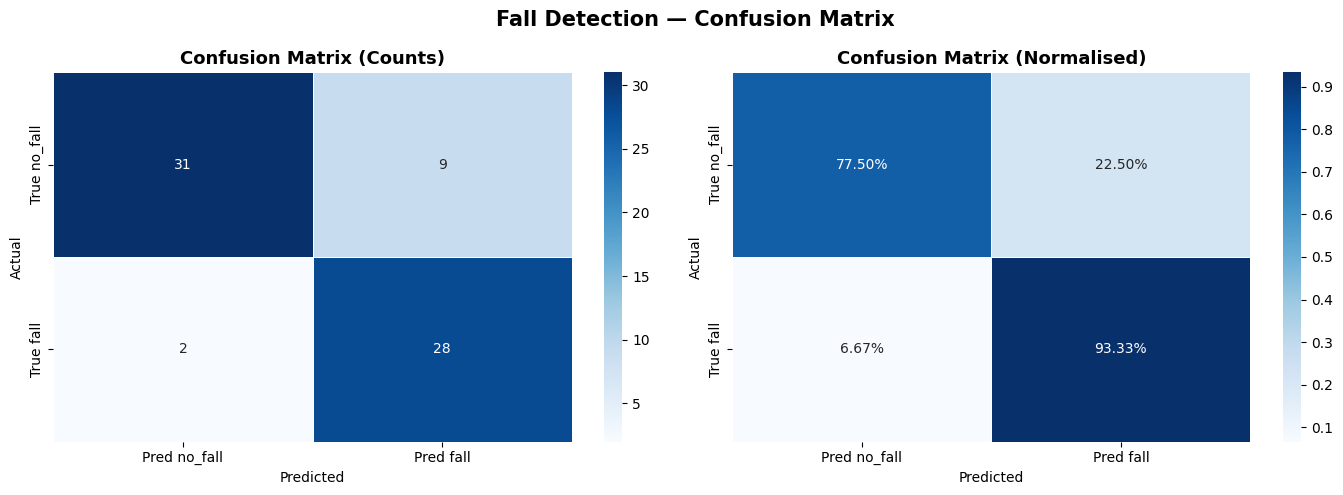

💾 confusion_matrix.png


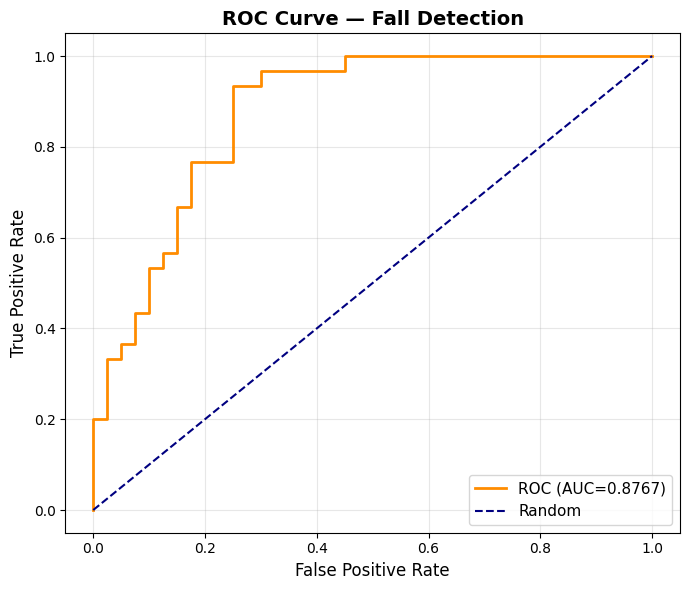

💾 roc_curve.png


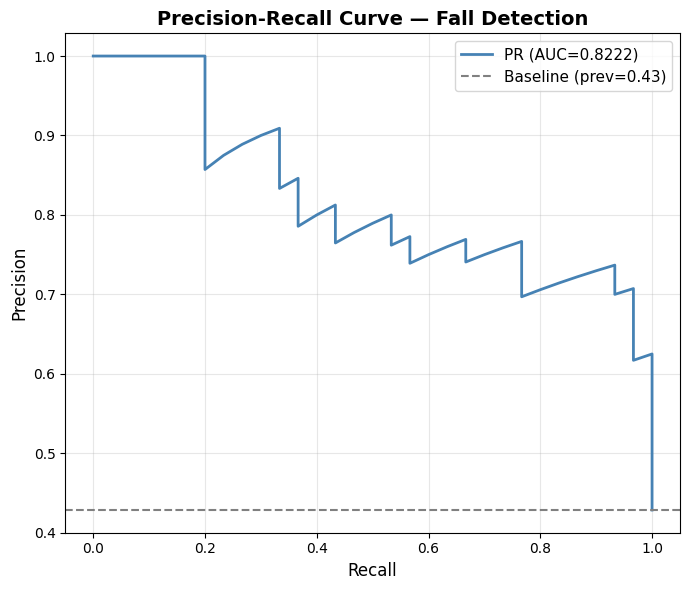

💾 pr_curve.png


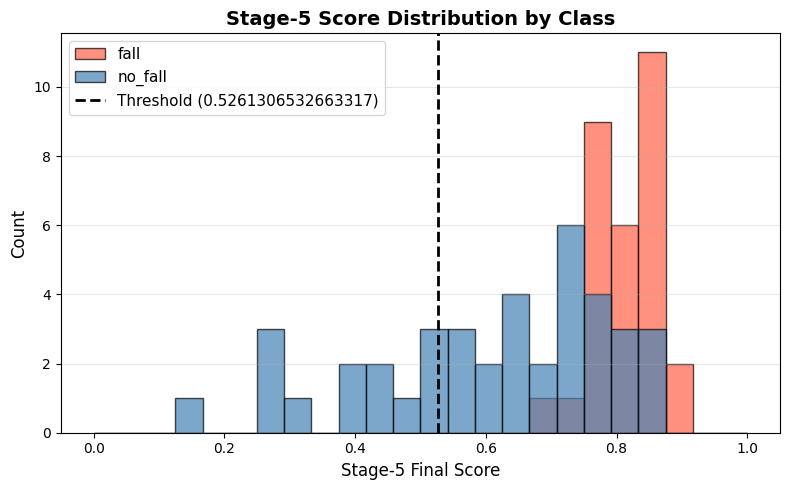

💾 score_distribution.png


KeyError: 'ensemble_probability'

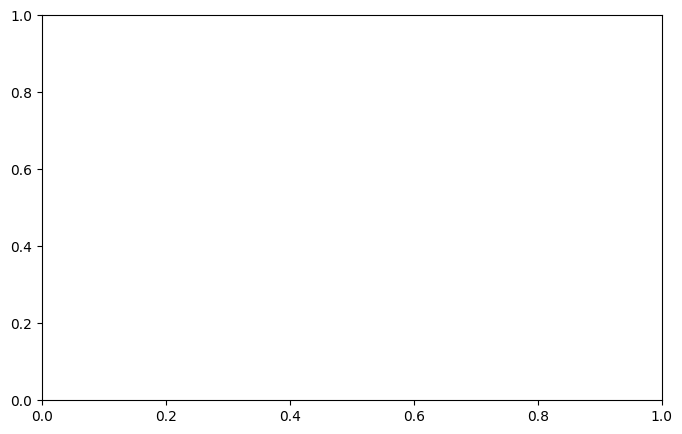

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURES
# ═══════════════════════════════════════════════════════════════════════════
auc_roc = roc_auc_score(y_true, y_score)
auc_pr  = average_precision_score(y_true, y_score)
bins    = np.linspace(0, 1, 25)

# ── Figure 1: Confusion Matrix ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred no_fall","Pred fall"],
            yticklabels=["True no_fall","True fall"],
            ax=axes[0], linewidths=0.5)
axes[0].set_title("Confusion Matrix (Counts)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Actual"); axes[0].set_xlabel("Predicted")
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=["Pred no_fall","Pred fall"],
            yticklabels=["True no_fall","True fall"],
            ax=axes[1], linewidths=0.5)
axes[1].set_title("Confusion Matrix (Normalised)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Actual"); axes[1].set_xlabel("Predicted")
plt.suptitle("Fall Detection \u2014 Confusion Matrix", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show(); print("\U0001f4be confusion_matrix.png")

# ── Figure 2: ROC Curve ───────────────────────────────────────────────────
fpr_arr, tpr_arr, _ = roc_curve(y_true, y_score)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_arr, tpr_arr, color="darkorange", lw=2, label=f"ROC (AUC={auc_roc:.4f})")
ax.plot([0,1],[0,1], "navy", lw=1.5, linestyle="--", label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve \u2014 Fall Detection", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/roc_curve.png", dpi=150)
plt.show(); print("\U0001f4be roc_curve.png")

# ── Figure 3: Precision-Recall Curve ──────────────────────────────────────
prec_arr, rec_arr, _ = precision_recall_curve(y_true, y_score)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(rec_arr, prec_arr, color="steelblue", lw=2, label=f"PR (AUC={auc_pr:.4f})")
baseline = y_true.sum() / len(y_true)
ax.axhline(baseline, linestyle="--", color="gray", lw=1.5,
           label=f"Baseline (prev={baseline:.2f})")
ax.set_xlabel("Recall", fontsize=12); ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curve \u2014 Fall Detection", fontsize=14, fontweight="bold")
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/pr_curve.png", dpi=150)
plt.show(); print("\U0001f4be pr_curve.png")

# ── Figure 4: Stage-5 Score Distribution ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df[df["label_int"]==1]["stage5_score"], bins=bins, alpha=0.7,
        color="tomato",    label="fall",    edgecolor="black", lw=0.6)
ax.hist(df[df["label_int"]==0]["stage5_score"], bins=bins, alpha=0.7,
        color="steelblue", label="no_fall", edgecolor="black", lw=0.6)
ax.axvline(dynamic_threshold, color="black", linestyle="--", lw=2,
           label=f"Threshold ({dynamic_threshold})")
ax.set_xlabel("Stage-5 Final Score", fontsize=12); ax.set_ylabel("Count", fontsize=12)
ax.set_title("Stage-5 Score Distribution by Class", fontsize=14, fontweight="bold")
ax.legend(fontsize=11); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("/content/score_distribution.png", dpi=150)
plt.show(); print("\U0001f4be score_distribution.png")

# ── Figure 5: Ensemble Probability Distribution ───────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df[df["label_int"]==1]["ensemble_probability"], bins=bins, alpha=0.7,
        color="tomato",    label="fall",    edgecolor="black", lw=0.6)
ax.hist(df[df["label_int"]==0]["ensemble_probability"], bins=bins, alpha=0.7,
        color="steelblue", label="no_fall", edgecolor="black", lw=0.6)
ax.axvline(0.5, color="black", linestyle="--", lw=2,
           label="Stage-4 threshold (0.5)")
ax.set_xlabel("Ensemble Probability", fontsize=12); ax.set_ylabel("Count", fontsize=12)
ax.set_title("BiLSTM Ensemble Probability Distribution", fontsize=14, fontweight="bold")
ax.legend(fontsize=11); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("/content/ensemble_prob_distribution.png", dpi=150)
plt.show(); print("\U0001f4be ensemble_prob_distribution.png")

# ── Figure 6: Per-environment BiLSTM probability distributions ────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ai, (env, col) in enumerate(zip(ENVIRONMENTS, ["prob_model_bed","prob_model_chair","prob_model_stand"])):
    axes[ai].hist(df[df["label_int"]==1][col], bins=bins, alpha=0.7,
                  color="tomato",    label="fall",    edgecolor="black", lw=0.6)
    axes[ai].hist(df[df["label_int"]==0][col], bins=bins, alpha=0.7,
                  color="steelblue", label="no_fall", edgecolor="black", lw=0.6)
    axes[ai].set_title(f"Model: {env}", fontsize=12, fontweight="bold")
    axes[ai].set_xlabel("Probability"); axes[ai].set_ylabel("Count")
    axes[ai].legend(fontsize=10); axes[ai].grid(axis="y", alpha=0.3)
plt.suptitle("Per-Environment BiLSTM Probability Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/per_env_distributions.png", dpi=150)
plt.show(); print("\U0001f4be per_env_distributions.png")

print("\n\u2705 All plots generated.")